import libraries


In [1]:
# Import required libraries for data analysis and statistics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm

# library for power analysis
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

 Power Analysis (Sample Size Calculation)

In [2]:
# baseline conversion rate
baseline_rate = 0.08

# expected treatment conversion rate
treatment_rate_expected = 0.095

# experiment parameters
alpha = 0.05
power = 0.80

# compute effect size
effect_size = proportion_effectsize(baseline_rate, treatment_rate_expected)

analysis = NormalIndPower()

sample_size = analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1
)

print("Required Sample Size Per Group:", round(sample_size))

Required Sample Size Per Group: 5561


generate dataset


In [3]:
# ensure reproducibility
np.random.seed(42)

# total users
n_users = 20000

# randomly assign users
groups = np.random.choice(['control','treatment'], size=n_users)

# create dataframe
data = pd.DataFrame({
    "user_id": range(1, n_users+1),
    "group": groups
})

Simulate Conversions

In [4]:
# conversion probabilities
control_rate = 0.08
treatment_rate = 0.095

# simulate conversions
data["converted"] = np.where(
    data["group"] == "control",
    np.random.binomial(1, control_rate, n_users),
    np.random.binomial(1, treatment_rate, n_users)
)

data.head()

,user_id,group,converted
0,1,control,0
1,2,treatment,0
2,3,control,0
3,4,control,0
4,5,control,0


In [14]:
data.to_csv("ab_test_dataset.csv", index=False)

EDA

In [15]:
# number of users per group
data["group"].value_counts()

group
control      10020
treatment     9980
Name: count, dtype: int64

In [16]:
# conversion counts
data.groupby("group")["converted"].sum()

group
control      851
treatment    971
Name: converted, dtype: int32

In [18]:
# conversion rate
conversion_rates = data.groupby("group")["converted"].mean()

print(conversion_rates)

group
control      0.084930
treatment    0.097295
Name: converted, dtype: float64


compute lift

In [19]:
control_rate = conversion_rates["control"]
treatment_rate = conversion_rates["treatment"]

lift = treatment_rate - control_rate

print("Control Rate:", control_rate)
print("Treatment Rate:", treatment_rate)
print("Lift:", lift)

Control Rate: 0.08493013972055888
Treatment Rate: 0.09729458917835672
Lift: 0.012364449457797841


Two Proportion Z-Test

In [20]:
# sample sizes
n_control = data[data.group=="control"].shape[0]
n_treatment = data[data.group=="treatment"].shape[0]

# conversions
conv_control = data[data.group=="control"]["converted"].sum()
conv_treatment = data[data.group=="treatment"]["converted"].sum()

# proportions
p1 = conv_control / n_control
p2 = conv_treatment / n_treatment

# pooled probability
p_pool = (conv_control + conv_treatment) / (n_control + n_treatment)

# standard error
se = np.sqrt(p_pool*(1-p_pool)*(1/n_control + 1/n_treatment))

# z statistic
z = (p2-p1)/se

# p value
p_value = 2*(1-norm.cdf(abs(z)))

print("Z statistic:", z)
print("P value:", p_value)

Z statistic: 3.0383771199531067
P value: 0.0023785608754323118


confidense interval

In [21]:
diff = p2 - p1

se_diff = np.sqrt(
    (p1*(1-p1)/n_control) +
    (p2*(1-p2)/n_treatment)
)

z_critical = 1.96

lower = diff - z_critical*se_diff
upper = diff + z_critical*se_diff

print("Lift:", diff)
print("95% CI:", (lower,upper))

Lift: 0.012364449457797841
95% CI: (np.float64(0.004389242257890056), np.float64(0.020339656657705624))


sample ratio mismatch check

In [22]:
group_counts = data.group.value_counts()

control_obs = group_counts["control"]
treatment_obs = group_counts["treatment"]

expected_ratio = 0.5

total = control_obs + treatment_obs

control_exp = total * expected_ratio
treatment_exp = total * expected_ratio

chi_square = ((control_obs-control_exp)**2/control_exp) + \
             ((treatment_obs-treatment_exp)**2/treatment_exp)

p_srm = 1 - norm.cdf(np.sqrt(chi_square))

print("Observed Control:",control_obs)
print("Observed Treatment:",treatment_obs)

print("SRM p value:",p_srm)

Observed Control: 10020
Observed Treatment: 9980
SRM p value: 0.3886487053947608


peeking simulation

In [23]:
data["day"] = np.random.randint(1,15,size=len(data))

daily_results = []

for day in range(1,15):

    subset = data[data.day <= day]

    control = subset[subset.group=="control"]
    treatment = subset[subset.group=="treatment"]

    n1 = len(control)
    n2 = len(treatment)

    if n1==0 or n2==0:
        continue

    c1 = control.converted.sum()
    c2 = treatment.converted.sum()

    p1 = c1/n1
    p2 = c2/n2

    p_pool = (c1+c2)/(n1+n2)

    se = np.sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2))

    z = (p2-p1)/se

    p_val = 2*(1-norm.cdf(abs(z)))

    daily_results.append([day,p_val])

peeking data frame

In [24]:
peek_df = pd.DataFrame(
    daily_results,
    columns=["day","p_value"]
)

peek_df.head()

,day,p_value
0,1,0.024920
1,2,0.005688
2,3,0.030025
3,4,0.075264
4,5,0.031423


Conversion Visualization

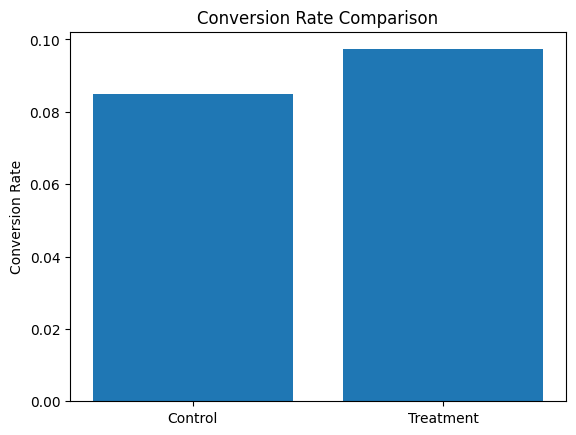

In [25]:
rates = [control_rate,treatment_rate]
labels = ["Control","Treatment"]

plt.bar(labels,rates)

plt.ylabel("Conversion Rate")
plt.title("Conversion Rate Comparison")

plt.show()

Peeking Visualization

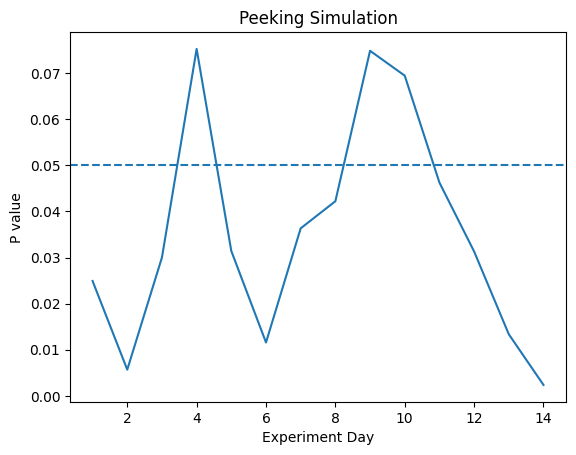

In [26]:
plt.plot(peek_df.day,peek_df.p_value)

plt.axhline(0.05,linestyle="--")

plt.xlabel("Experiment Day")
plt.ylabel("P value")

plt.title("Peeking Simulation")

plt.show()

In [27]:
print("===== Experiment Summary =====")

print("Control Conversion:",round(control_rate,4))
print("Treatment Conversion:",round(treatment_rate,4))

print("Lift:",round(diff,4))

print("P value:",p_value)

print("Confidence Interval:",(lower,upper))

if p_value < 0.05:
    print("Treatment significantly improves conversion")
else:
    print("No significant difference")

===== Experiment Summary =====
Control Conversion: 0.0849
Treatment Conversion: 0.0973
Lift: 0.0124
P value: 0.0023785608754323118
Confidence Interval: (np.float64(0.004389242257890056), np.float64(0.020339656657705624))
Treatment significantly improves conversion


A/B Testing Analysis for Website Conversion Optimization

Goal:
Evaluate whether a new website design improves conversion rate.

Methods:
- Power analysis
- Conversion rate analysis
- Two-proportion Z-test
- Confidence interval estimation
- Sample ratio mismatch detection
- Peeking simulation

Tools:
Python, Pandas, NumPy, SciPy, Matplotlib